In [34]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [3]:
!pip install dagshub mlflow

### Imports

In [5]:
import warnings
warnings.filterwarnings('ignore')
 
import numpy as np
import pandas as pd
from scipy import stats
 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display
 
from sklearn.model_selection import (StratifiedKFold, cross_val_score,
                                     RandomizedSearchCV, train_test_split)
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.feature_selection import (RFE, SelectFromModel,
                                       VarianceThreshold, mutual_info_classif)
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay)
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
 
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier, Pool
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
 
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm
import dagshub
 
import gc
import time
import pickle
import json
from collections import Counter
 
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
 
print("All imports successful.")

All imports successful.


### Dagshub & MLflow Setup

In [35]:
DAGSHUB_USERNAME = "gormo22"
DAGSHUB_REPO     = "ML-FraudDetection"
 
dagshub.init(repo_owner=DAGSHUB_USERNAME,
             repo_name=DAGSHUB_REPO,
             mlflow=True)
 
MLFLOW_TRACKING_URI = f"https://dagshub.com/{DAGSHUB_USERNAME}/{DAGSHUB_REPO}.mlflow"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
 
print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")
 
# Paths
DATA_DIR   = "/kaggle/input/competitions/ieee-fraud-detection/"
OUTPUT_DIR = "/kaggle/working/"
SEED       = 42
N_FOLDS    = 5

Initialized MLflow to track repo "gormo22/ML-FraudDetection"

Repository gormo22/ML-FraudDetection initialized!

MLflow tracking URI: https://dagshub.com/gormo22/ML-FraudDetection.mlflow


### Reduce memory usage (large data)

In [36]:
def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    print(f"Memory usage before: {start_mem:.2f} MB")

    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()

            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                df[col] = df[col].astype(np.float32)
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print(f"Memory usage after: {end_mem:.2f} MB")
    print(f"Reduced by {(100 * (start_mem - end_mem) / start_mem):.1f}%")

    return df


print("Loading datasets...")

train_trans = pd.read_csv(DATA_DIR + "train_transaction.csv")
train_id    = pd.read_csv(DATA_DIR + "train_identity.csv")

test_trans  = pd.read_csv(DATA_DIR + "test_transaction.csv")
test_id     = pd.read_csv(DATA_DIR + "test_identity.csv")

print("Merging datasets...")

train = train_trans.merge(train_id, on="TransactionID", how="left")
test  = test_trans.merge(test_id, on="TransactionID", how="left")

del train_trans, train_id, test_trans, test_id
gc.collect()

train = reduce_mem_usage(train)
test  = reduce_mem_usage(test)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

display(train.head())

Loading datasets...
Merging datasets...
Memory usage before: 1955.37 MB
Memory usage after: 924.29 MB
Reduced by 52.7%
Memory usage before: 1673.87 MB
Memory usage after: 792.58 MB
Reduced by 52.6%
Train shape: (590540, 434)
Test shape: (506691, 433)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


### EDA & Plotting 

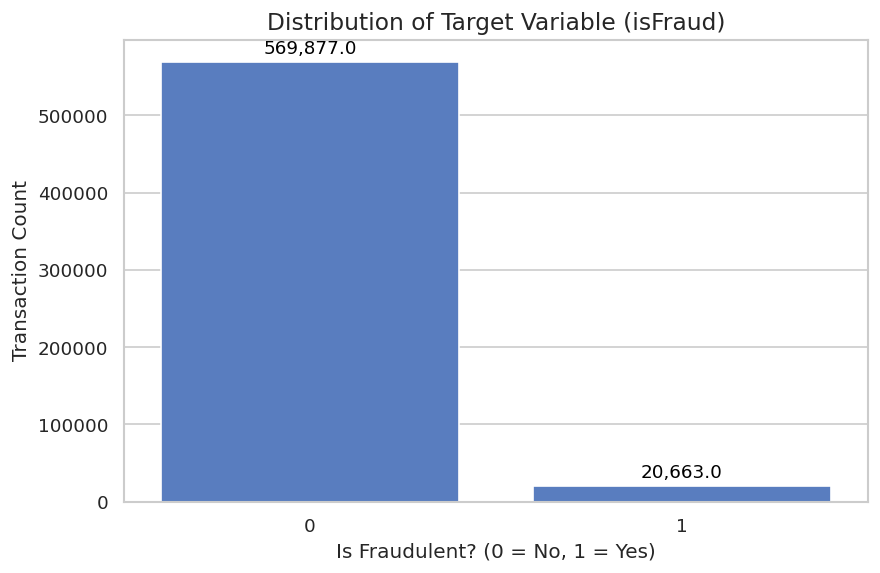

Percentage of fraudulent transactions: 3.50%

Standardizing test column names...
Analyzing missing values...


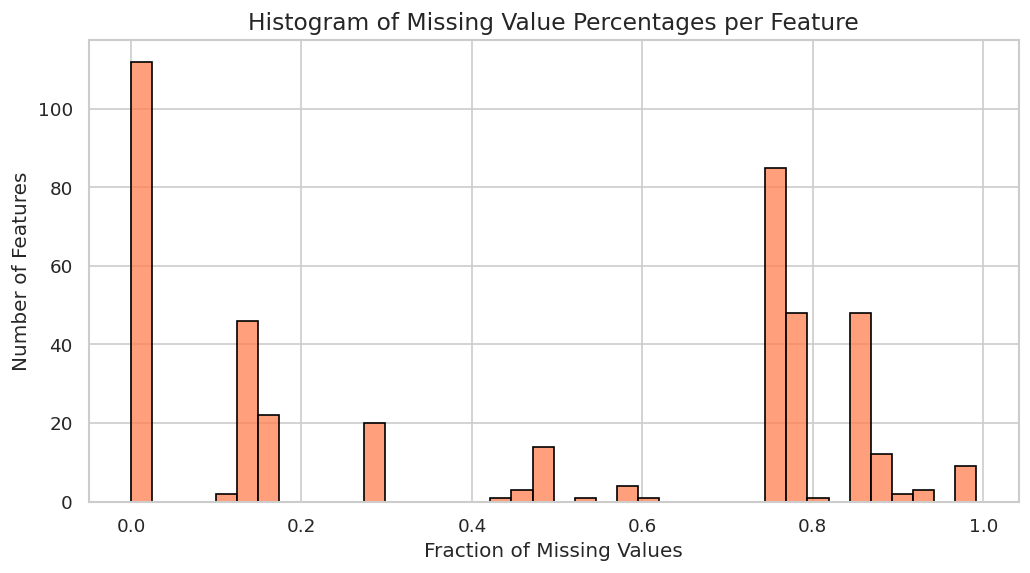

Dropping 74 columns with more than 80.0% missing values...
Train shape after cleaning: (590540, 360)
Test shape after cleaning: (506691, 359)


In [9]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='isFraud', data=train)
plt.title('Distribution of Target Variable (isFraud)', fontsize=14)
plt.ylabel('Transaction Count', fontsize=12)
plt.xlabel('Is Fraudulent? (0 = No, 1 = Yes)', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

if 'isFraud' in train.columns:
    fraud_pct = train['isFraud'].mean() * 100
    print(f"Percentage of fraudulent transactions: {fraud_pct:.2f}%\n")


print("Standardizing test column names...")
test.columns = test.columns.str.replace('-', '_')


print("Analyzing missing values...")
missing_train = train.isnull().sum() / len(train)

plt.figure(figsize=(10, 5))
sns.histplot(missing_train, bins=40, color='coral', edgecolor='black')
plt.title('Histogram of Missing Value Percentages per Feature', fontsize=14)
plt.xlabel('Fraction of Missing Values', fontsize=12)
plt.ylabel('Number of Features', fontsize=12)
plt.show()


THRESHOLD = 0.80
cols_to_drop = missing_train[missing_train > THRESHOLD].index.tolist()

if 'isFraud' in cols_to_drop:
    cols_to_drop.remove('isFraud')

print(f"Dropping {len(cols_to_drop)} columns with more than {THRESHOLD*100}% missing values...")

train.drop(columns=cols_to_drop, errors='ignore', inplace=True)
test.drop(columns=cols_to_drop, errors='ignore', inplace=True)

gc.collect()

print(f"Train shape after cleaning: {train.shape}")
print(f"Test shape after cleaning: {test.shape}")

### Transaction amount deep dive

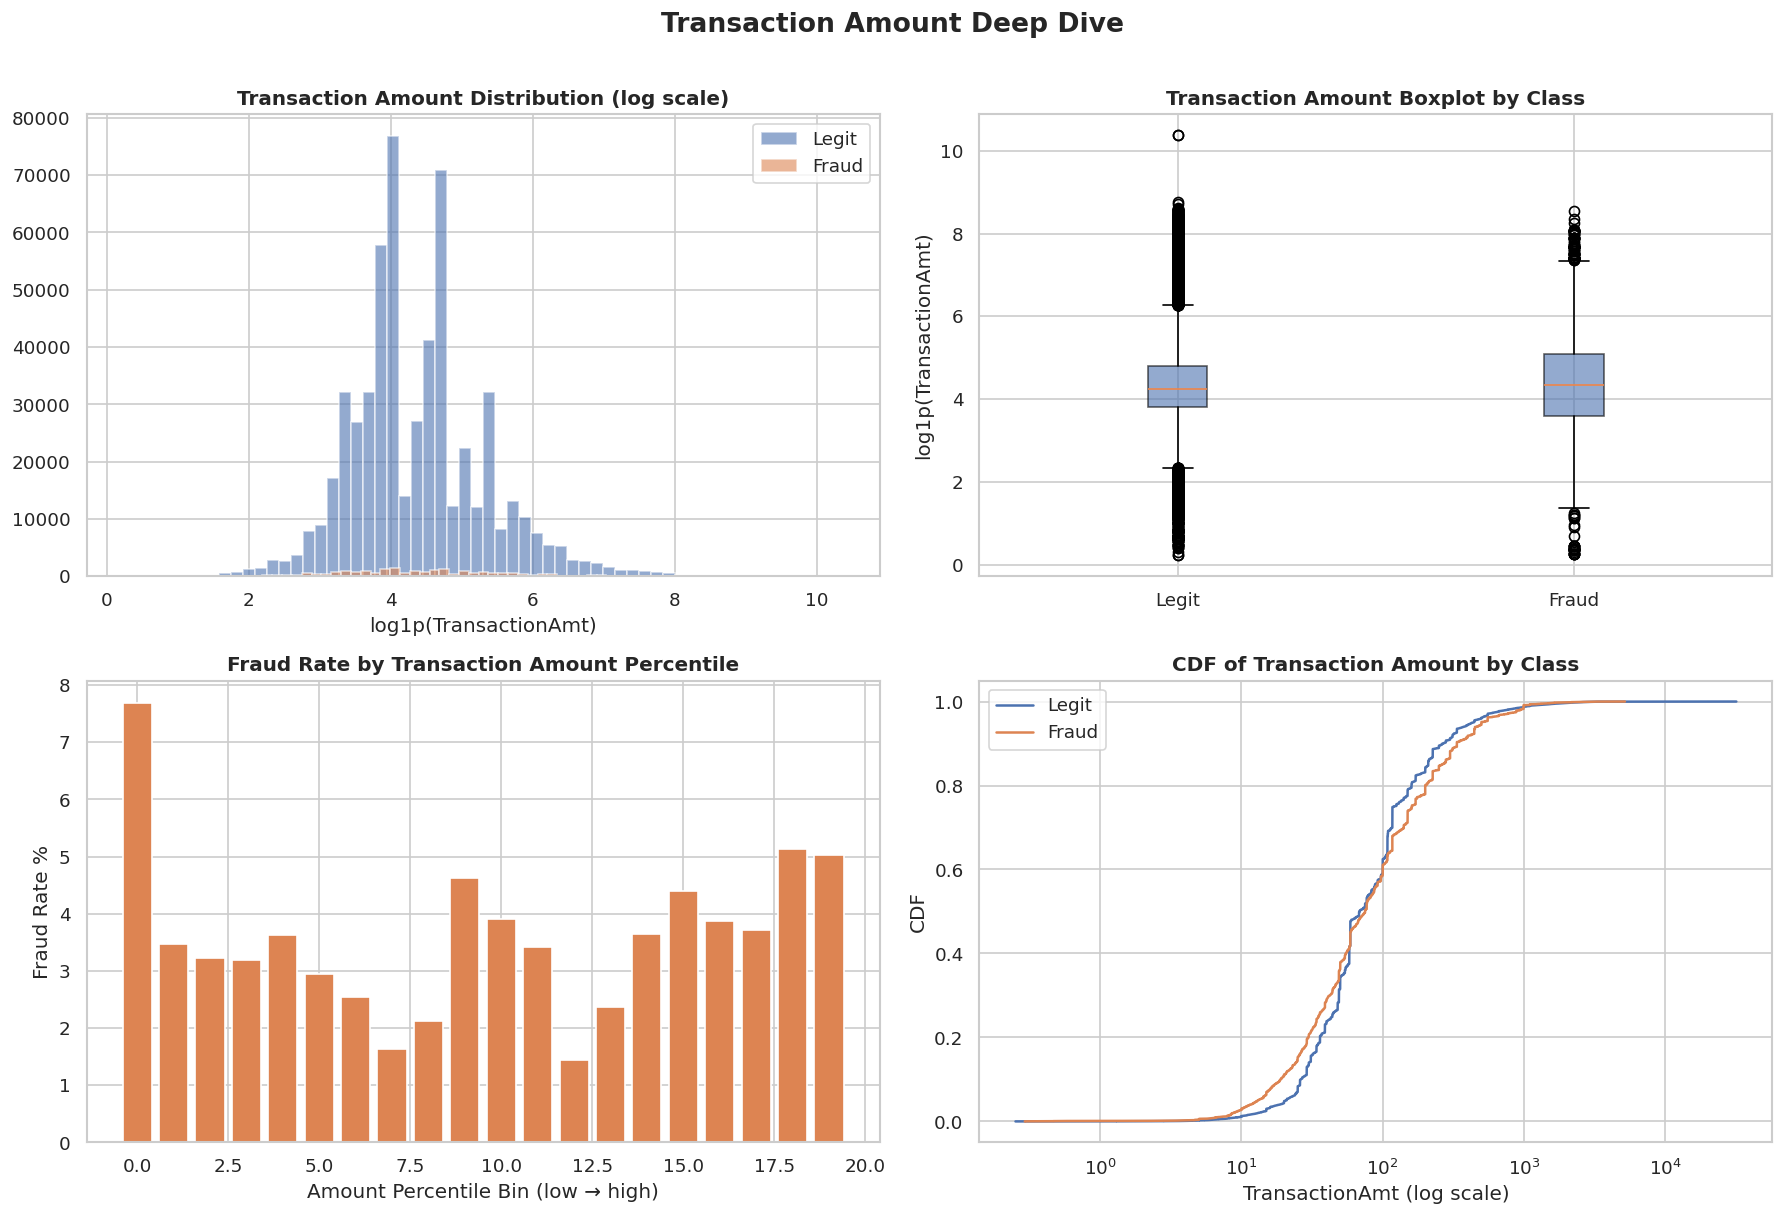

In [10]:
with mlflow.start_run(run_name="EDA_TransactionAmt", experiment_id=mlflow.get_experiment_by_name("EDA").experiment_id):
 
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
 
    for label, color in [(0, '#4C72B0'), (1, '#DD8452')]:
        subset = np.log1p(train.loc[train['isFraud'] == label, 'TransactionAmt'])
        axes[0, 0].hist(subset, bins=60, alpha=0.6,
                        color=color, label=f"{'Fraud' if label else 'Legit'}",
                        edgecolor='white')
    axes[0, 0].set_xlabel("log1p(TransactionAmt)")
    axes[0, 0].set_title("Transaction Amount Distribution (log scale)", fontweight='bold')
    axes[0, 0].legend()
 
    # Box plot
    train_plot = train[['isFraud', 'TransactionAmt']].copy()
    train_plot['TransactionAmt'] = np.log1p(train_plot['TransactionAmt'])
    axes[0, 1].boxplot(
        [train_plot.loc[train_plot['isFraud']==0, 'TransactionAmt'],
         train_plot.loc[train_plot['isFraud']==1, 'TransactionAmt']],
        labels=['Legit', 'Fraud'],
        patch_artist=True,
        boxprops=dict(facecolor='#4C72B0', alpha=0.6)
    )
    axes[0, 1].set_ylabel("log1p(TransactionAmt)")
    axes[0, 1].set_title("Transaction Amount Boxplot by Class", fontweight='bold')
 
    train['amt_bin'] = pd.qcut(train['TransactionAmt'], q=20, duplicates='drop')
    fraud_by_bin = train.groupby('amt_bin')['isFraud'].mean() * 100
    axes[1, 0].bar(range(len(fraud_by_bin)), fraud_by_bin.values, color='#DD8452')
    axes[1, 0].set_xlabel("Amount Percentile Bin (low → high)")
    axes[1, 0].set_ylabel("Fraud Rate %")
    axes[1, 0].set_title("Fraud Rate by Transaction Amount Percentile", fontweight='bold')
 
    axes[1, 1].plot(np.sort(train.loc[train['isFraud']==0, 'TransactionAmt'].values),
                    np.linspace(0, 1, (train['isFraud']==0).sum()),
                    label='Legit', color='#4C72B0')
    axes[1, 1].plot(np.sort(train.loc[train['isFraud']==1, 'TransactionAmt'].values),
                    np.linspace(0, 1, (train['isFraud']==1).sum()),
                    label='Fraud', color='#DD8452')
    axes[1, 1].set_xscale('log')
    axes[1, 1].set_xlabel("TransactionAmt (log scale)")
    axes[1, 1].set_ylabel("CDF")
    axes[1, 1].set_title("CDF of Transaction Amount by Class", fontweight='bold')
    axes[1, 1].legend()
 
    plt.suptitle("Transaction Amount Deep Dive", fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + "transaction_amt_eda.png", bbox_inches='tight')
    mlflow.log_artifact(OUTPUT_DIR + "transaction_amt_eda.png")
    plt.show()
 
    train.drop(columns=['amt_bin'], inplace=True)
 


### Time-based patterns

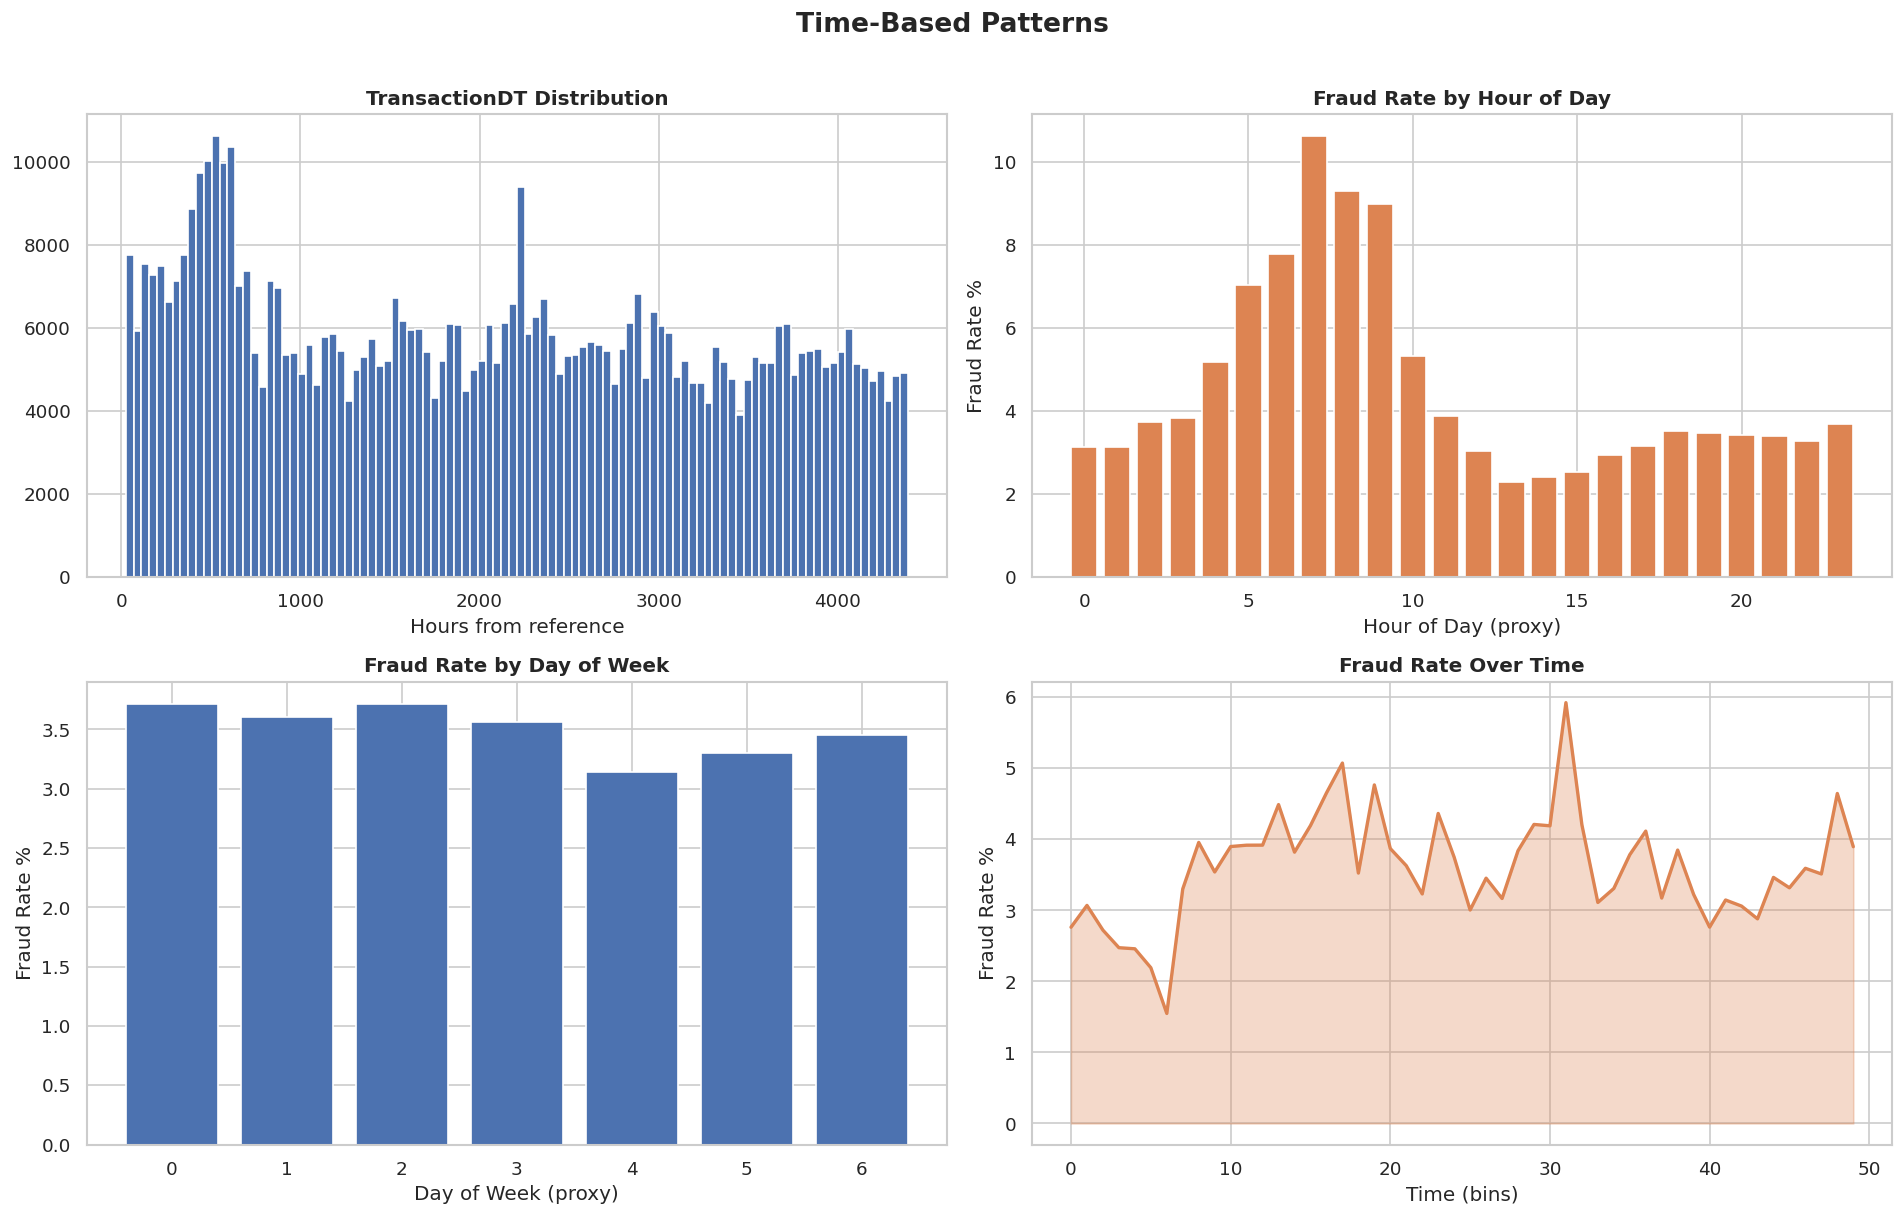

In [11]:
with mlflow.start_run(run_name="EDA_Time_Analysis", experiment_id=mlflow.get_experiment_by_name("EDA").experiment_id):
 
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    dt = train['TransactionDT']
 
    axes[0, 0].hist(dt / 3600, bins=100, color='#4C72B0', edgecolor='white')
    axes[0, 0].set_xlabel("Hours from reference")
    axes[0, 0].set_title("TransactionDT Distribution", fontweight='bold')
 
    train['hour'] = (train['TransactionDT'] // 3600) % 24
    fraud_by_hour = train.groupby('hour')['isFraud'].mean() * 100
    axes[0, 1].bar(fraud_by_hour.index, fraud_by_hour.values, color='#DD8452')
    axes[0, 1].set_xlabel("Hour of Day (proxy)")
    axes[0, 1].set_ylabel("Fraud Rate %")
    axes[0, 1].set_title("Fraud Rate by Hour of Day", fontweight='bold')
 
    train['day_of_week'] = (train['TransactionDT'] // 86400) % 7
    fraud_by_dow = train.groupby('day_of_week')['isFraud'].mean() * 100
    axes[1, 0].bar(fraud_by_dow.index, fraud_by_dow.values,
                   color='#4C72B0', edgecolor='white')
    axes[1, 0].set_xlabel("Day of Week (proxy)")
    axes[1, 0].set_ylabel("Fraud Rate %")
    axes[1, 0].set_title("Fraud Rate by Day of Week", fontweight='bold')
 
    bins = pd.cut(train['TransactionDT'], bins=50)
    vol  = train.groupby(bins)['isFraud'].agg(['sum', 'count'])
    vol['fraud_rate'] = vol['sum'] / vol['count'] * 100
    axes[1, 1].plot(range(len(vol)), vol['fraud_rate'], color='#DD8452', linewidth=2)
    axes[1, 1].fill_between(range(len(vol)), vol['fraud_rate'], alpha=0.3, color='#DD8452')
    axes[1, 1].set_xlabel("Time (bins)")
    axes[1, 1].set_ylabel("Fraud Rate %")
    axes[1, 1].set_title("Fraud Rate Over Time", fontweight='bold')
 
    plt.suptitle("Time-Based Patterns", fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + "time_eda.png", bbox_inches='tight')
    mlflow.log_artifact(OUTPUT_DIR + "time_eda.png")
    plt.show()
 
    train.drop(columns=['hour', 'day_of_week'], inplace=True, errors='ignore')
 


### Categorical features 

Loading data …
Train: (590540, 432)  Test: (506691, 432)
Fitting pipeline on train …
Processed train shape : (590540, 92)
Processed test  shape : (506691, 92)


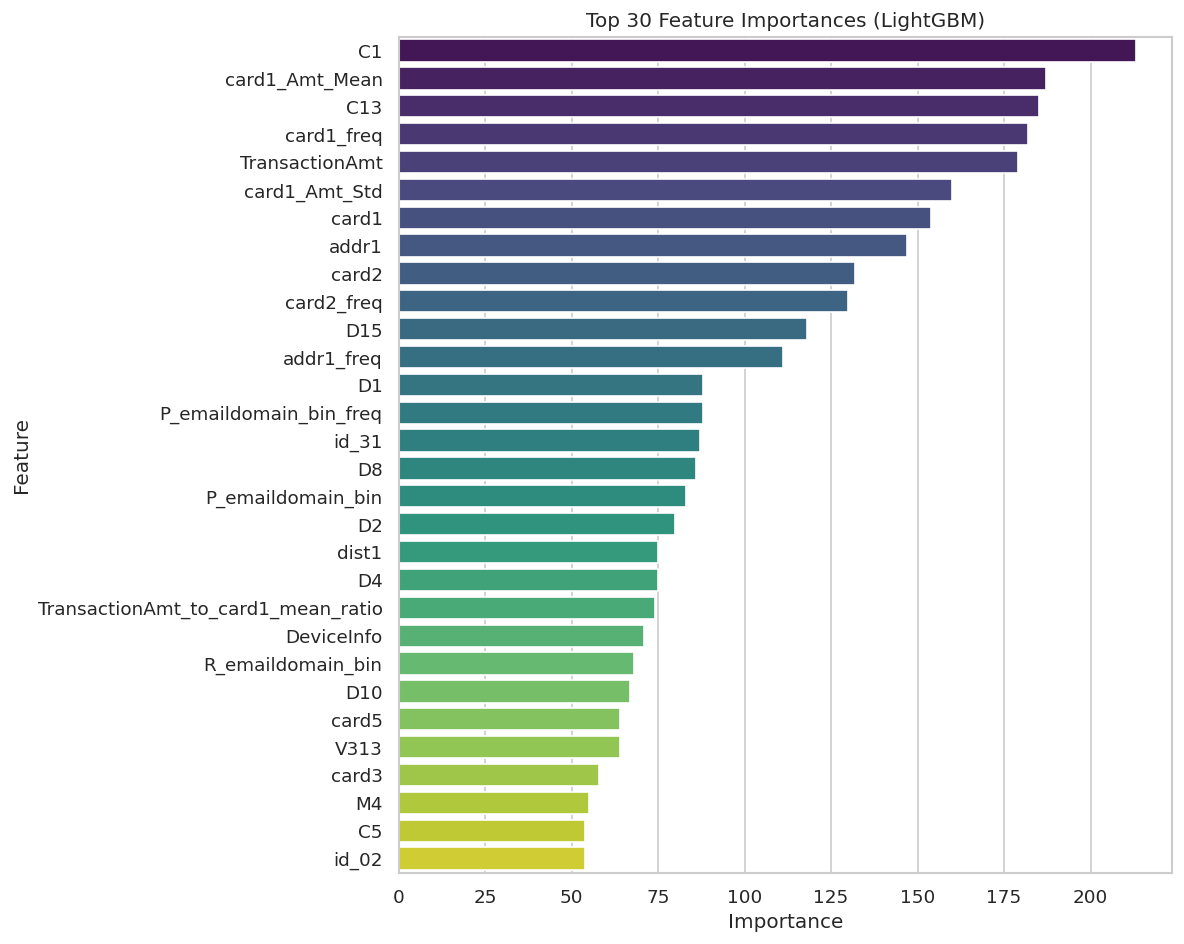


MLflow run_id: db51fa4aeb9b4858a3f3c82232f17a01


In [40]:
import gc
import pickle
import tempfile
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import mlflow
import mlflow.sklearn

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import mutual_info_classif, RFE
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

DATA_DIR   = "/kaggle/input/competitions/ieee-fraud-detection/"
OUTPUT_DIR = "/kaggle/working/"
SEED       = 42
MLFLOW_EXP = "FraudPipeline"

mlflow.set_experiment(MLFLOW_EXP)

def reduce_mem_usage(df):
    for col in df.columns:
        col_type = df[col].dtype
        if col_type == object:
            df[col] = df[col].astype("category")
        elif str(col_type)[:3] == "int":
            c_min, c_max = df[col].min(), df[col].max()
            if   c_min > np.iinfo(np.int8).min  and c_max < np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            else:
                df[col] = df[col].astype(np.int32)
        else:
            df[col] = df[col].astype(np.float32)
    return df

class TimeFeatureExtractor(BaseEstimator, TransformerMixin):
    """Extract cyclical hour/day features from TransactionDT. Stateless."""
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        if "TransactionDT" in X.columns:
            X["Transaction_day_of_week"] = np.floor((X["TransactionDT"] / (3600 * 24) - 1) % 7)
            X["Transaction_hour"]        = np.floor(X["TransactionDT"] / 3600) % 24
            X["Transaction_hour_sin"]    = np.sin(X["Transaction_hour"] * (2 * np.pi / 24))
            X["Transaction_hour_cos"]    = np.cos(X["Transaction_hour"] * (2 * np.pi / 24))
            X["Transaction_day_sin"]     = np.sin(X["Transaction_day_of_week"] * (2 * np.pi / 7))
            X["Transaction_day_cos"]     = np.cos(X["Transaction_day_of_week"] * (2 * np.pi / 7))
            X.drop("TransactionDT", axis=1, inplace=True)
        return X


class EmailDomainBinner(BaseEstimator, TransformerMixin):
    """Bin email domain to first segment (gmail, yahoo …). Stateless."""
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col in ["P_emaildomain", "R_emaildomain"]:
            if col in X.columns:
                X[col + "_bin"] = (
                    X[col].astype(str)
                    .replace("nan", "missing")
                    .apply(lambda v: v.split(".")[0])
                )
                X.drop(col, axis=1, inplace=True)
        return X


class NumericalImputer(BaseEstimator, TransformerMixin):
    """Fill numeric NaN with -999, categorical NaN with 'missing'. Stateless."""
    def fit(self, X, y=None):
        self.num_cols_ = X.select_dtypes(include=[np.number]).columns.tolist()
        self.cat_cols_ = X.select_dtypes(include=["object", "category"]).columns.tolist()
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.num_cols_:
            if col in X.columns:
                X[col] = X[col].fillna(-999)
        for col in self.cat_cols_:
            if col in X.columns:
                X[col] = X[col].astype(str).replace("nan", "missing")
        return X


class SafeLabelEncoder(BaseEstimator, TransformerMixin):
    """
    Label-encode all object/category columns.
    FIX: fitted on TRAIN only; unseen test values mapped to -1.
    """
    def fit(self, X, y=None):
        self.cat_cols_ = X.select_dtypes(include=["object", "category"]).columns.tolist()
        # Also encode any string cols added by EmailDomainBinner
        extra = [c for c in X.columns if "_bin" in c and c not in self.cat_cols_]
        self.cat_cols_ = list(set(self.cat_cols_ + extra))
        self.encoders_ = {}
        for col in self.cat_cols_:
            le = LabelEncoder()
            le.fit(X[col].astype(str).values)
            self.encoders_[col] = le
        return self

    def transform(self, X):
        X = X.copy()
        for col, le in self.encoders_.items():
            if col not in X.columns:
                continue
            vals = X[col].astype(str).values
            known = set(le.classes_)
            # Map unseen categories to "__unknown__" which gets encoded as -1
            mapped = np.where(np.isin(vals, list(known)), vals, "__unknown__")
            # Temporarily extend encoder for unseen
            if "__unknown__" not in known:
                le.classes_ = np.append(le.classes_, "__unknown__")
            X[col] = le.transform(mapped).astype(np.int32)
        return X


class ConstantColumnDropper(BaseEstimator, TransformerMixin):
    """
    Drop columns that have ≤1 unique value.
    FIX: detected on TRAIN only (inside .fit()).
    """
    def fit(self, X, y=None):
        self.drop_cols_ = [c for c in X.columns if X[c].nunique() <= 1]
        return self

    def transform(self, X):
        return X.drop(columns=[c for c in self.drop_cols_ if c in X.columns])


class CardAggFeatures(BaseEstimator, TransformerMixin):
    """
    Card × TransactionAmt aggregation features.
    FIX: mean/std computed on TRAIN only, then mapped.
    """
    def fit(self, X, y=None):
        self.card1_mean_ = X.groupby("card1")["TransactionAmt"].mean()
        self.card1_std_  = X.groupby("card1")["TransactionAmt"].std().fillna(0)
        self.card4_mean_ = X.groupby("card4")["TransactionAmt"].mean()
        return self

    def transform(self, X):
        X = X.copy()
        X["card1_Amt_Mean"] = X["card1"].map(self.card1_mean_)
        X["card1_Amt_Std"]  = X["card1"].map(self.card1_std_).fillna(0)
        X["card4_Amt_Mean"] = X["card4"].map(self.card4_mean_)
        X["TransactionAmt_to_card1_mean_ratio"] = (
            X["TransactionAmt"] / X["card1_Amt_Mean"].replace(0, np.nan)
        )
        X["TransactionAmt_to_card4_mean_ratio"] = (
            X["TransactionAmt"] / X["card4_Amt_Mean"].replace(0, np.nan)
        )
        return X


class FrequencyEncoder(BaseEstimator, TransformerMixin):
    """
    Frequency-encode high-cardinality columns.
    FIX: frequencies computed on TRAIN only.
    """
    FREQ_COLS = ["card1", "card2", "card3", "addr1", "addr2", "P_emaildomain_bin"]

    def fit(self, X, y=None):
        self.freq_maps_ = {}
        for col in self.FREQ_COLS:
            if col in X.columns:
                self.freq_maps_[col] = X[col].value_counts().to_dict()
        return self

    def transform(self, X):
        X = X.copy()
        for col, freq_map in self.freq_maps_.items():
            if col in X.columns:
                X[col + "_freq"] = X[col].map(freq_map).fillna(0)
        return X


class CorrelationFilter(BaseEstimator, TransformerMixin):
    """Drop features with pairwise correlation > threshold (computed on train sample)."""
    def __init__(self, threshold=0.90, sample_frac=0.2):
        self.threshold   = threshold
        self.sample_frac = sample_frac

    def fit(self, X, y=None):
        sample = X.sample(frac=self.sample_frac, random_state=SEED)
        corr   = sample.corr().abs()
        upper  = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        self.drop_cols_ = [c for c in upper.columns if any(upper[c] > self.threshold)]
        return self

    def transform(self, X):
        return X.drop(columns=[c for c in self.drop_cols_ if c in X.columns])


class MIFilter(BaseEstimator, TransformerMixin):
    """Drop features with near-zero mutual information (computed on train sample)."""
    def __init__(self, threshold=1e-4, sample_frac=0.10):
        self.threshold   = threshold
        self.sample_frac = sample_frac

    def fit(self, X, y):
        X_s, _, y_s, _ = train_test_split(
            X, y, test_size=1 - self.sample_frac, stratify=y, random_state=SEED
        )
        scores = mutual_info_classif(X_s, y_s, random_state=SEED)
        self.drop_cols_ = [c for c, s in zip(X.columns, scores) if s < self.threshold]
        return self

    def transform(self, X):
        return X.drop(columns=[c for c in self.drop_cols_ if c in X.columns])

class ZeroImportanceDropper(BaseEstimator, TransformerMixin):
    """Drop features with zero LightGBM importance (fitted on full train)."""
    def fit(self, X, y):
        clf = lgb.LGBMClassifier(
            n_estimators=150, max_depth=7,
            random_state=SEED, n_jobs=-1, verbose=-1
        )
        clf.fit(X, y)
        
        self.keep_cols_ = [
            c for c, imp in zip(X.columns, clf.feature_importances_) if imp > 0
        ]
        
        self.drop_cols_ = [
            c for c, imp in zip(X.columns, clf.feature_importances_) if imp <= 0
        ]
        
        return self

    def transform(self, X):
        return X[[c for c in self.keep_cols_ if c in X.columns]]
        
class RFESelector(BaseEstimator, TransformerMixin):
    """RFE feature selection (fitted on train sample)."""
    def __init__(self, n_features=100, step=10, sample_frac=0.10):
        self.n_features  = n_features
        self.step        = step
        self.sample_frac = sample_frac

    def fit(self, X, y):
        n = min(self.n_features, X.shape[1])
        X_s, _, y_s, _ = train_test_split(
            X, y, test_size=1 - self.sample_frac, stratify=y, random_state=SEED
        )
        lgb_est = lgb.LGBMClassifier(
            n_estimators=100, max_depth=5,
            random_state=SEED, n_jobs=-1, verbose=-1
        )
        rfe = RFE(estimator=lgb_est, n_features_to_select=n, step=self.step)
        rfe.fit(X_s, y_s)
        self.selected_cols_ = X.columns[rfe.support_].tolist()
        return self

    def transform(self, X):

        missing = [c for c in self.selected_cols_ if c not in X.columns]
        if missing:
            print(f"[RFESelector] WARNING: {len(missing)} selected cols missing "
                  f"in this split, filling with -999: {missing}")
            for c in missing:
                X = X.copy()
                X[c] = -999
        return X[self.selected_cols_]


class ZeroImportanceDropper(BaseEstimator, TransformerMixin):
    """Drop features with zero LightGBM importance (fitted on full train)."""
    def fit(self, X, y):
        clf = lgb.LGBMClassifier(
            n_estimators=150, max_depth=7,
            random_state=SEED, n_jobs=-1, verbose=-1
        )
        clf.fit(X, y)
        self.keep_cols_ = [
            c for c, imp in zip(X.columns, clf.feature_importances_) if imp > 0
        ]
        return self

    def transform(self, X):
        # Select only kept columns — test always has same cols as train here
        return X[[c for c in self.keep_cols_ if c in X.columns]]


print("Loading data …")
train = pd.read_csv(DATA_DIR + "train_transaction.csv").merge(
    pd.read_csv(DATA_DIR + "train_identity.csv"), on="TransactionID", how="left"
)
test = pd.read_csv(DATA_DIR + "test_transaction.csv").merge(
    pd.read_csv(DATA_DIR + "test_identity.csv"), on="TransactionID", how="left"
)
train = reduce_mem_usage(train)
test  = reduce_mem_usage(test)

train_ids = train["TransactionID"].copy()
test_ids  = test["TransactionID"].copy()

y_train = train.pop("isFraud")
X_train = train.drop(columns=["TransactionID"])
X_test  = test.drop(columns=["TransactionID"])

print(f"Train: {X_train.shape}  Test: {X_test.shape}")
gc.collect()


#  BUILD PIPELINE
pipeline = Pipeline([
    ("time_features",    TimeFeatureExtractor()),
    ("email_bin",        EmailDomainBinner()),
    ("imputer",          NumericalImputer()),
    ("label_enc",        SafeLabelEncoder()),
    ("constant_drop",    ConstantColumnDropper()),
    ("card_agg",         CardAggFeatures()),
    ("freq_enc",         FrequencyEncoder()),
    ("corr_filter",      CorrelationFilter(threshold=0.90, sample_frac=0.20)),
    ("mi_filter",        MIFilter(threshold=1e-4, sample_frac=0.10)),
    ("rfe",              RFESelector(n_features=100, step=10, sample_frac=0.10)),
    ("zero_imp_drop",    ZeroImportanceDropper()),
])


with mlflow.start_run(run_name="FraudFeaturePipeline") as run:

    print("Fitting pipeline on train …")
    X_train_proc = pipeline.fit_transform(X_train, y_train)
    X_test_proc  = pipeline.transform(X_test)

    print(f"Processed train shape : {X_train_proc.shape}")
    print(f"Processed test  shape : {X_test_proc.shape}")

    # ── log params ──────────────────────────────────────────────────────────
    mlflow.log_params({
        "corr_threshold"    : pipeline.named_steps["corr_filter"].threshold,
        "corr_sample_frac"  : pipeline.named_steps["corr_filter"].sample_frac,
        "mi_threshold"      : pipeline.named_steps["mi_filter"].threshold,
        "mi_sample_frac"    : pipeline.named_steps["mi_filter"].sample_frac,
        "rfe_n_features"    : pipeline.named_steps["rfe"].n_features,
        "rfe_step"          : pipeline.named_steps["rfe"].step,
        "rfe_sample_frac"   : pipeline.named_steps["rfe"].sample_frac,
    })

    mlflow.log_metrics({
        "features_after_corr_filter" : X_train.shape[1]
            - len(pipeline.named_steps["corr_filter"].drop_cols_),
        "features_after_mi_filter"   : len(pipeline.named_steps["rfe"].selected_cols_),
        "features_final"             : X_train_proc.shape[1],
        "dropped_constant_cols"      : len(pipeline.named_steps["constant_drop"].drop_cols_),
        "dropped_zero_importance"    : len(pipeline.named_steps["zero_imp_drop"].drop_cols_),
    })

    with tempfile.TemporaryDirectory() as tmp:
        pkl_path = os.path.join(tmp, "fraud_pipeline.pkl")
        with open(pkl_path, "wb") as f:
            pickle.dump(pipeline, f)
        mlflow.log_artifact(pkl_path, artifact_path="pipeline")

    final_cols = list(X_train_proc.columns) if hasattr(X_train_proc, "columns") \
                 else pipeline.named_steps["rfe"].selected_cols_

    clf = lgb.LGBMClassifier(n_estimators=150, max_depth=7,
                              random_state=SEED, n_jobs=-1, verbose=-1)
    clf.fit(X_train_proc, y_train)
    imp_df = (pd.DataFrame({"Feature": final_cols,
                             "Importance": clf.feature_importances_})
              .sort_values("Importance", ascending=False))

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.barplot(x="Importance", y="Feature", data=imp_df.head(30),
                palette="viridis", ax=ax)
    ax.set_title("Top 30 Feature Importances (LightGBM)")
    plt.tight_layout()
    with tempfile.TemporaryDirectory() as tmp:
        fig_path = os.path.join(tmp, "feature_importance.png")
        fig.savefig(fig_path, bbox_inches="tight")
        mlflow.log_artifact(fig_path, artifact_path="plots")
    plt.show()

    RUN_ID = run.info.run_id
    print(f"\nMLflow run_id: {RUN_ID}")




## Training
### ---XGBoost---

In [55]:
def objective_xgb(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 400, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 3.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 5.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 5.0, log=True),

        'random_state': SEED,
        'n_jobs': -1,
        'eval_metric': 'auc',
        'tree_method': 'hist',
        'use_label_encoder': False
    }

    print("\n" + "=" * 60)
    print(f"Trial {trial.number}")
    print("=" * 60)

    val_scores = []
    oof_preds = np.zeros(len(y))

    with mlflow.start_run(run_name=f"xgb_trial_{trial.number}", nested=True):
        mlflow.log_params(params)

        for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):

            print(f"\nFold {fold + 1}")

            X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
            X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

            model = xgb.XGBClassifier(**params)

            model.fit(
                X_tr, y_tr,
                eval_set=[(X_val, y_val)],
                verbose=False
            )

            # predictions
            tr_pred = model.predict_proba(X_tr)[:, 1]
            val_pred = model.predict_proba(X_val)[:, 1]

            oof_preds[val_idx] = val_pred

            # metrics
            tr_auc = roc_auc_score(y_tr, tr_pred)
            val_auc = roc_auc_score(y_val, val_pred)

            val_scores.append(val_auc)

            print(f"Train AUC: {tr_auc:.5f}")
            print(f"Val   AUC: {val_auc:.5f}")

            mlflow.log_metric("val_auc", val_auc, step=fold)
            mlflow.log_metric("train_auc", tr_auc, step=fold)


        avg_val = np.mean(val_scores)

        print("\n" + "-" * 60)
        print(f"Avg Val AUC: {avg_val:.5f}")

        mlflow.log_metric("avg_val_auc", avg_val)

        import matplotlib.pyplot as plt
        from sklearn.metrics import RocCurveDisplay

        plt.figure()
        RocCurveDisplay.from_predictions(y, oof_preds)
        plt.title(f"ROC Curve - Trial {trial.number}")

        plt.show()

        return avg_val


Trial 0

Fold 1
Train AUC: 0.89111
Val   AUC: 0.89059

Fold 2
Train AUC: 0.89091
Val   AUC: 0.89131

Fold 3
Train AUC: 0.89271
Val   AUC: 0.88534

Fold 4
Train AUC: 0.89181
Val   AUC: 0.88692

Fold 5
Train AUC: 0.89154
Val   AUC: 0.88892

------------------------------------------------------------
Avg Val AUC: 0.88861


<Figure size 768x576 with 0 Axes>

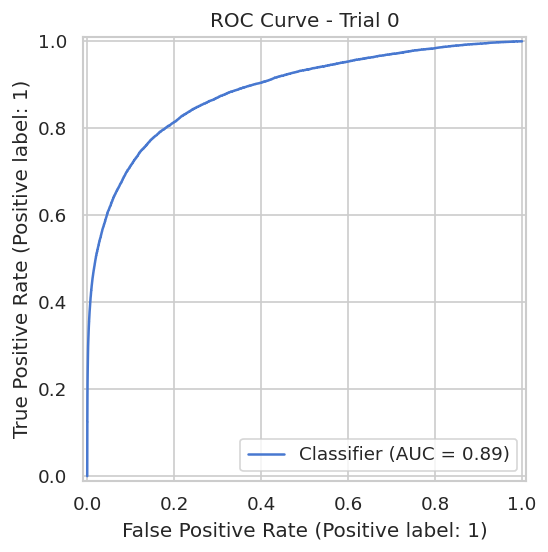


Trial 1

Fold 1
Train AUC: 0.89933
Val   AUC: 0.89802

Fold 2
Train AUC: 0.89904
Val   AUC: 0.89794

Fold 3
Train AUC: 0.90112
Val   AUC: 0.89241

Fold 4
Train AUC: 0.90106
Val   AUC: 0.89500

Fold 5
Train AUC: 0.90045
Val   AUC: 0.89651

------------------------------------------------------------
Avg Val AUC: 0.89598


<Figure size 768x576 with 0 Axes>

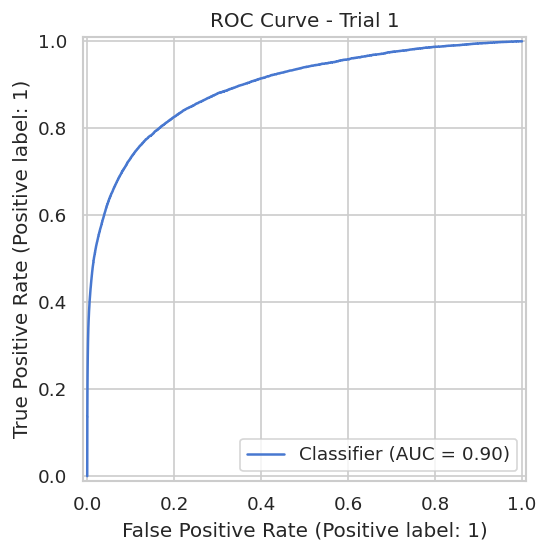


Trial 2

Fold 1
Train AUC: 0.95981
Val   AUC: 0.94369

Fold 2
Train AUC: 0.95882
Val   AUC: 0.94250

Fold 3
Train AUC: 0.95879
Val   AUC: 0.93873

Fold 4
Train AUC: 0.95966
Val   AUC: 0.94126

Fold 5
Train AUC: 0.95893
Val   AUC: 0.94233

------------------------------------------------------------
Avg Val AUC: 0.94170


<Figure size 768x576 with 0 Axes>

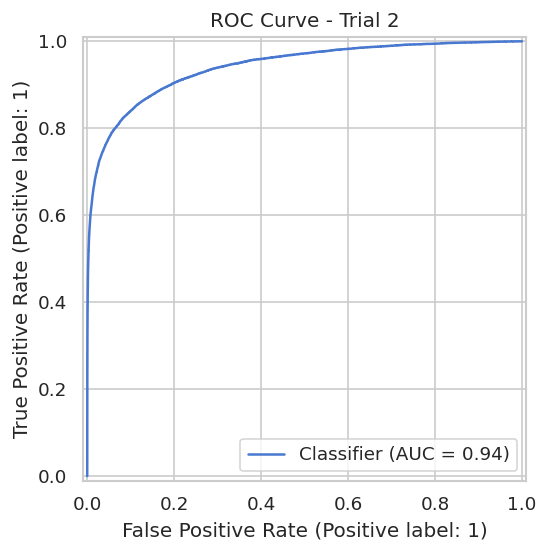


Trial 3

Fold 1
Train AUC: 0.94054
Val   AUC: 0.93032

Fold 2
Train AUC: 0.93908
Val   AUC: 0.92885

Fold 3
Train AUC: 0.94028
Val   AUC: 0.92452

Fold 4
Train AUC: 0.94077
Val   AUC: 0.92772

Fold 5
Train AUC: 0.94047
Val   AUC: 0.92967

------------------------------------------------------------
Avg Val AUC: 0.92822


<Figure size 768x576 with 0 Axes>

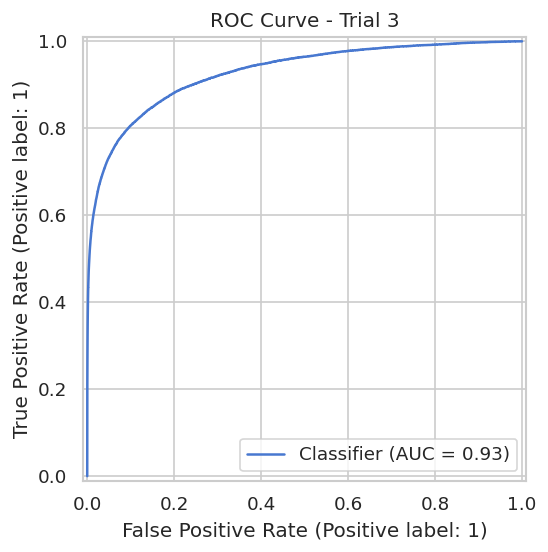


Trial 4

Fold 1
Train AUC: 0.94066
Val   AUC: 0.92842

Fold 2
Train AUC: 0.94024
Val   AUC: 0.92799

Fold 3
Train AUC: 0.94208
Val   AUC: 0.92486

Fold 4
Train AUC: 0.94172
Val   AUC: 0.92635

Fold 5
Train AUC: 0.94114
Val   AUC: 0.92533

------------------------------------------------------------
Avg Val AUC: 0.92659


<Figure size 768x576 with 0 Axes>

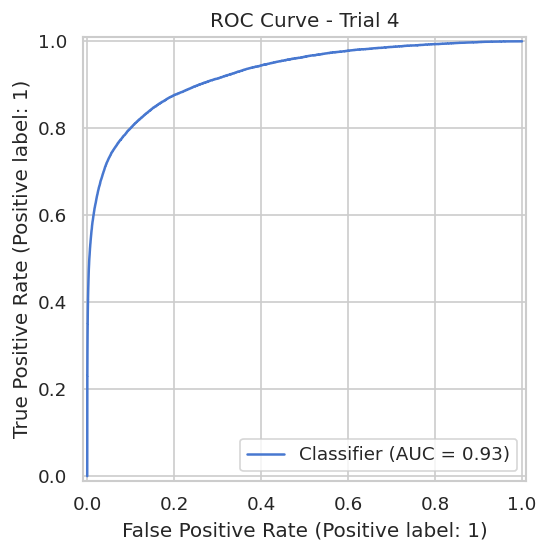

0.9417019457995878
{'n_estimators': 350, 'learning_rate': 0.12241669155085556, 'max_depth': 5, 'min_child_weight': 2, 'subsample': 0.7816894259800234, 'colsample_bytree': 0.7241086775326306, 'gamma': 1.9499583354168442, 'reg_alpha': 0.02437110461325228, 'reg_lambda': 0.017622848277112767}


In [57]:
X = X_train_proc
y = y_train

mlflow.set_experiment("xgboost")

study = optuna.create_study(direction="maximize")
study.optimize(objective_xgb, n_trials=5)

print(study.best_value)
print(study.best_params)

### ---LightGBM---

In [58]:
import mlflow
import optuna
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score


def objective_lgbm(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 600, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 20, 256),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'subsample_freq': 1,
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 10.0, log=True),

        'random_state': SEED,
        'n_jobs': -1,
        'verbose': -1
    }

    print("\n" + "=" * 60)
    print(f"Trial {trial.number}")
    print("=" * 60)

    val_scores, train_scores = [], []
    oof_preds = np.zeros(len(y_train))

    with mlflow.start_run(run_name=f"lgbm_trial_{trial.number}", nested=True):
        mlflow.log_params(params)

        for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_proc, y_train)):

            print(f"\nFold {fold + 1}")

            X_tr, y_tr = X_train_proc.iloc[tr_idx], y_train.iloc[tr_idx]
            X_val, y_val = X_train_proc.iloc[val_idx], y_train.iloc[val_idx]

            model = lgb.LGBMClassifier(**params)

            model.fit(
                X_tr,
                y_tr,
                eval_set=[(X_val, y_val)],
                eval_metric="auc"
            )

            tr_pred = model.predict_proba(X_tr)[:, 1]
            val_pred = model.predict_proba(X_val)[:, 1]

            oof_preds[val_idx] = val_pred

            tr_auc = roc_auc_score(y_tr, tr_pred)
            val_auc = roc_auc_score(y_val, val_pred)

            train_scores.append(tr_auc)
            val_scores.append(val_auc)

            print(f"Train AUC: {tr_auc:.5f}")
            print(f"Val   AUC: {val_auc:.5f}")

            mlflow.log_metric("train_auc", tr_auc, step=fold)
            mlflow.log_metric("val_auc", val_auc, step=fold)


        avg_train = np.mean(train_scores)
        avg_val = np.mean(val_scores)
        gap = avg_train - avg_val

        print("\n" + "-" * 60)
        print(f"Avg Train AUC: {avg_train:.5f}")
        print(f"Avg Val   AUC: {avg_val:.5f}")
        print(f"Overfit Gap  : {gap:.5f}")

        mlflow.log_metric("avg_train_auc", avg_train)
        mlflow.log_metric("avg_val_auc", avg_val)
        mlflow.log_metric("overfit_gap", gap)


        from sklearn.metrics import RocCurveDisplay

        plt.figure()
        RocCurveDisplay.from_predictions(y_train, oof_preds)
        plt.title(f"ROC Curve - Trial {trial.number}")
        plt.show()


        importance = model.feature_importances_
        indices = np.argsort(importance)[-20:]

        plt.figure(figsize=(10, 6))
        plt.barh(range(len(indices)), importance[indices])
        plt.yticks(range(len(indices)), X_train_proc.columns[indices])
        plt.title(f"Feature Importance - Trial {trial.number}")
        plt.tight_layout()

        plot_path = f"fi_lgbm_trial_{trial.number}.png"
        plt.savefig(plot_path)
        mlflow.log_artifact(plot_path)
        plt.close()

        mlflow.lightgbm.log_model(model, "model")

        return avg_val


Trial 0

Fold 1
Train AUC: 0.95243
Val   AUC: 0.93869

Fold 2
Train AUC: 0.95248
Val   AUC: 0.93820

Fold 3
Train AUC: 0.95308
Val   AUC: 0.93452

Fold 4
Train AUC: 0.95403
Val   AUC: 0.93727

Fold 5
Train AUC: 0.95332
Val   AUC: 0.93825

------------------------------------------------------------
Avg Train AUC: 0.95307
Avg Val   AUC: 0.93739
Overfit Gap  : 0.01568


<Figure size 768x576 with 0 Axes>

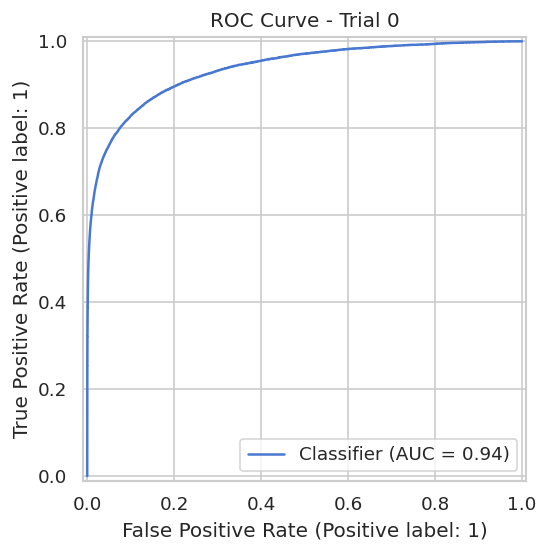


Trial 1

Fold 1
Train AUC: 0.92278
Val   AUC: 0.91813

Fold 2
Train AUC: 0.92226
Val   AUC: 0.91764

Fold 3
Train AUC: 0.92367
Val   AUC: 0.91248

Fold 4
Train AUC: 0.92458
Val   AUC: 0.91562

Fold 5
Train AUC: 0.92391
Val   AUC: 0.91782

------------------------------------------------------------
Avg Train AUC: 0.92344
Avg Val   AUC: 0.91634
Overfit Gap  : 0.00710


<Figure size 768x576 with 0 Axes>

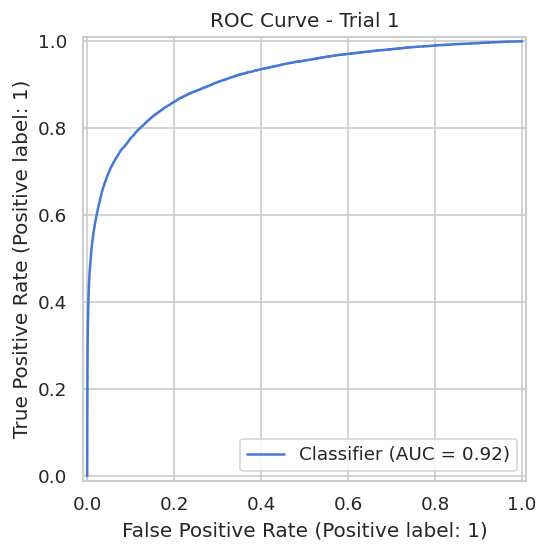


Trial 2

Fold 1
Train AUC: 0.91922
Val   AUC: 0.91184

Fold 2
Train AUC: 0.91874
Val   AUC: 0.91273

Fold 3
Train AUC: 0.91948
Val   AUC: 0.90646

Fold 4
Train AUC: 0.92016
Val   AUC: 0.90932

Fold 5
Train AUC: 0.92000
Val   AUC: 0.90865

------------------------------------------------------------
Avg Train AUC: 0.91952
Avg Val   AUC: 0.90980
Overfit Gap  : 0.00972


<Figure size 768x576 with 0 Axes>

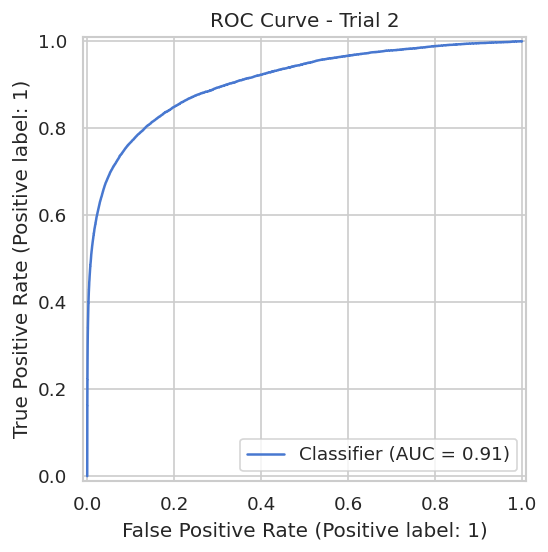


Trial 3

Fold 1
Train AUC: 0.98262
Val   AUC: 0.95396

Fold 2
Train AUC: 0.98151
Val   AUC: 0.95354

Fold 3
Train AUC: 0.98239
Val   AUC: 0.95364

Fold 4
Train AUC: 0.98202
Val   AUC: 0.95465

Fold 5
Train AUC: 0.98195
Val   AUC: 0.95517

------------------------------------------------------------
Avg Train AUC: 0.98210
Avg Val   AUC: 0.95419
Overfit Gap  : 0.02791


<Figure size 768x576 with 0 Axes>

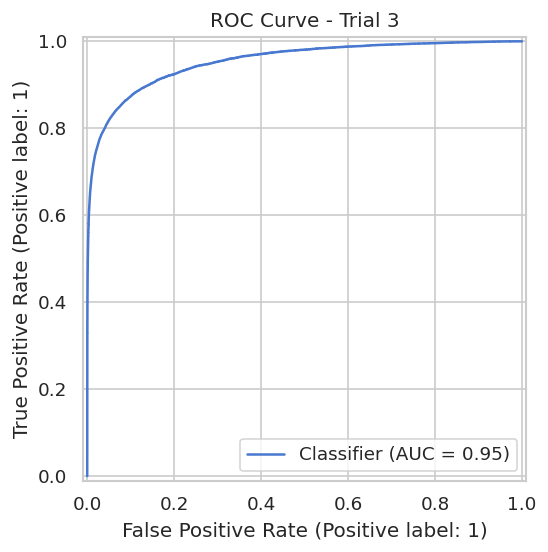


Trial 4

Fold 1
Train AUC: 0.96351
Val   AUC: 0.94489

Fold 2
Train AUC: 0.96457
Val   AUC: 0.94521

Fold 3
Train AUC: 0.96491
Val   AUC: 0.94375

Fold 4
Train AUC: 0.96505
Val   AUC: 0.94582

Fold 5
Train AUC: 0.96370
Val   AUC: 0.94480

------------------------------------------------------------
Avg Train AUC: 0.96435
Avg Val   AUC: 0.94489
Overfit Gap  : 0.01945


<Figure size 768x576 with 0 Axes>

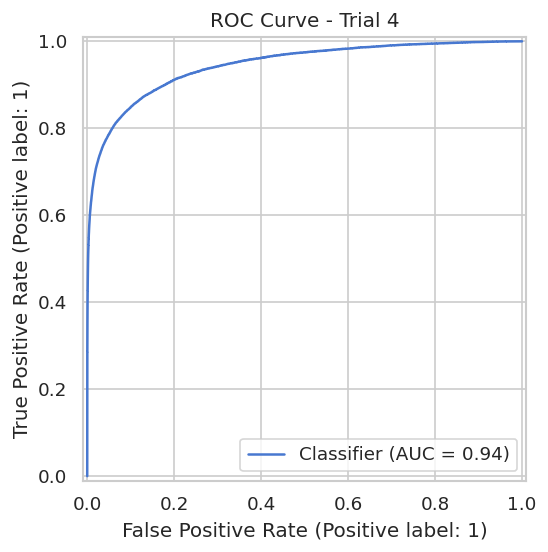


Trial 5

Fold 1
Train AUC: 0.94907
Val   AUC: 0.93480

Fold 2
Train AUC: 0.94916
Val   AUC: 0.93521

Fold 3
Train AUC: 0.94936
Val   AUC: 0.93090

Fold 4
Train AUC: 0.95018
Val   AUC: 0.93327

Fold 5
Train AUC: 0.94922
Val   AUC: 0.93247

------------------------------------------------------------
Avg Train AUC: 0.94940
Avg Val   AUC: 0.93333
Overfit Gap  : 0.01607


<Figure size 768x576 with 0 Axes>

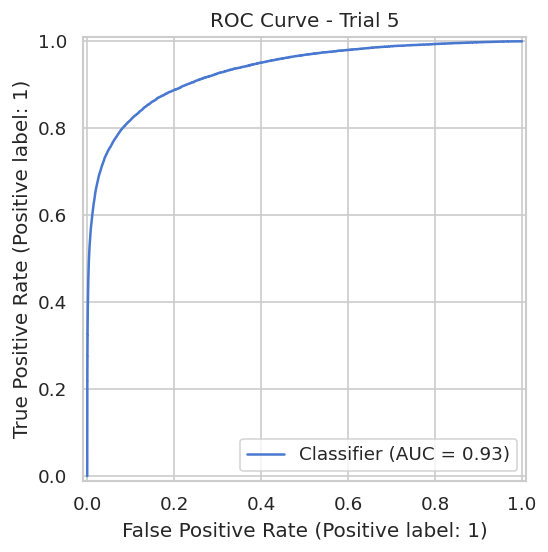


Trial 6

Fold 1
Train AUC: 0.88790
Val   AUC: 0.88747

Fold 2
Train AUC: 0.88740
Val   AUC: 0.88785

Fold 3
Train AUC: 0.88900
Val   AUC: 0.88229

Fold 4
Train AUC: 0.88878
Val   AUC: 0.88397

Fold 5
Train AUC: 0.88840
Val   AUC: 0.88526

------------------------------------------------------------
Avg Train AUC: 0.88830
Avg Val   AUC: 0.88537
Overfit Gap  : 0.00293


<Figure size 768x576 with 0 Axes>

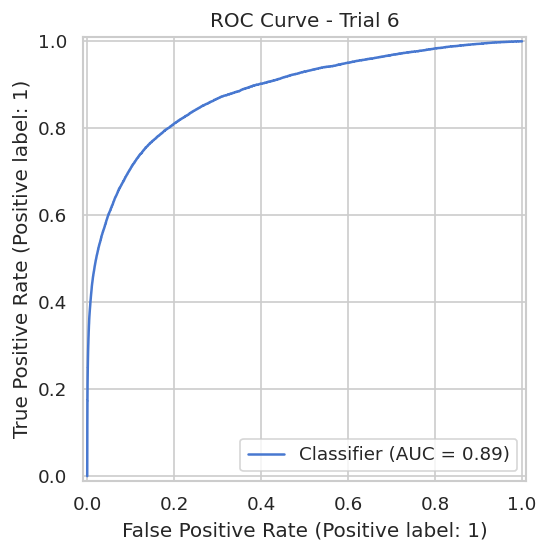


Trial 7

Fold 1
Train AUC: 0.97530
Val   AUC: 0.95320

Fold 2
Train AUC: 0.97470
Val   AUC: 0.95227

Fold 3
Train AUC: 0.97506
Val   AUC: 0.94988

Fold 4
Train AUC: 0.97378
Val   AUC: 0.95164

Fold 5
Train AUC: 0.97425
Val   AUC: 0.95058

------------------------------------------------------------
Avg Train AUC: 0.97462
Avg Val   AUC: 0.95152
Overfit Gap  : 0.02310


<Figure size 768x576 with 0 Axes>

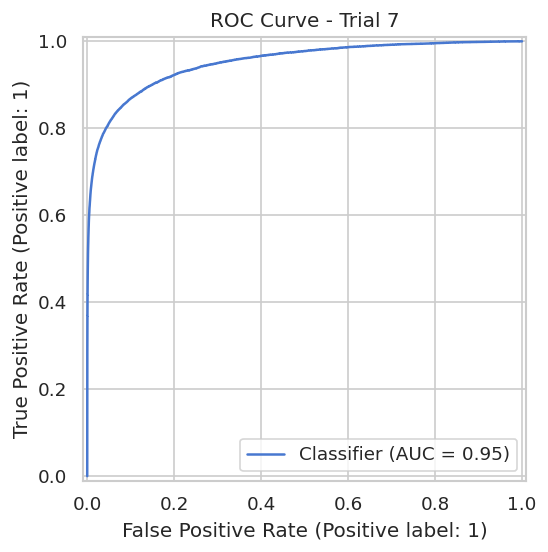


Trial 8

Fold 1
Train AUC: 0.99746
Val   AUC: 0.96865

Fold 2
Train AUC: 0.99737
Val   AUC: 0.96845

Fold 3
Train AUC: 0.99740
Val   AUC: 0.96928

Fold 4
Train AUC: 0.99738
Val   AUC: 0.97095

Fold 5
Train AUC: 0.99747
Val   AUC: 0.96906

------------------------------------------------------------
Avg Train AUC: 0.99741
Avg Val   AUC: 0.96928
Overfit Gap  : 0.02814


<Figure size 768x576 with 0 Axes>

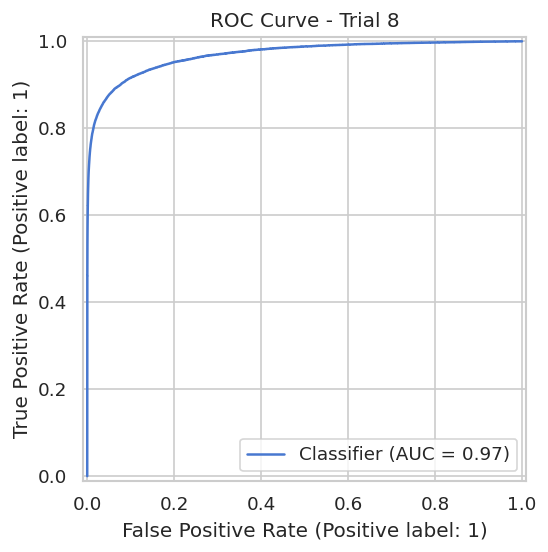


Trial 9

Fold 1
Train AUC: 0.98267
Val   AUC: 0.95967

Fold 2
Train AUC: 0.98259
Val   AUC: 0.95922

Fold 3
Train AUC: 0.98308
Val   AUC: 0.95868

Fold 4
Train AUC: 0.98326
Val   AUC: 0.96033

Fold 5
Train AUC: 0.98265
Val   AUC: 0.95923

------------------------------------------------------------
Avg Train AUC: 0.98285
Avg Val   AUC: 0.95942
Overfit Gap  : 0.02343


<Figure size 768x576 with 0 Axes>

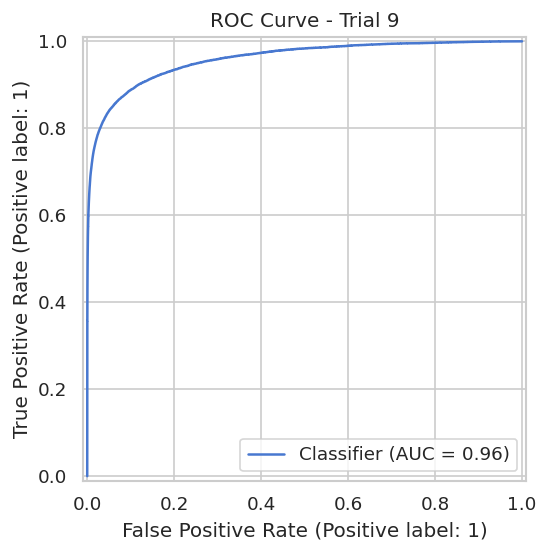

0.9692781056686195
{'n_estimators': 500, 'learning_rate': 0.11152007992725553, 'max_depth': 10, 'num_leaves': 118, 'min_child_samples': 54, 'subsample': 0.9193923796599198, 'colsample_bytree': 0.6638482671829391, 'reg_alpha': 0.0027348720891590427, 'reg_lambda': 2.106909629878799}


In [61]:
mlflow.set_experiment("lightgbm")

study_lgbm = optuna.create_study(direction="maximize")

study_lgbm.optimize(objective_lgbm, n_trials=10)

print(study_lgbm.best_value)
print(study_lgbm.best_params)

In [62]:
import mlflow
import optuna
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')


def objective_lr(trial):

    mlflow.set_experiment("FraudDetection_LogReg")

    params = {
        'C': trial.suggest_float('C', 1e-4, 10.0, log=True),
        'class_weight': 'balanced',
        'max_iter': 500,
        'random_state': SEED
    }

    print("\n" + "=" * 70)
    print(f"LogReg Trial {trial.number}")
    print("-" * 70)

    val_aucs, train_aucs = [], []
    oof_preds = np.zeros(len(y_train))

    with mlflow.start_run(run_name=f"lr_trial_{trial.number}", nested=True):

        mlflow.log_params(params)

        for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_proc, y_train)):

            X_tr, y_tr = X_train_proc.iloc[train_idx], y_train.iloc[train_idx]
            X_v, y_v = X_train_proc.iloc[val_idx], y_train.iloc[val_idx]

            pipeline = Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('lr', LogisticRegression(**params))
            ])

            pipeline.fit(X_tr, y_tr)

            tr_pred = pipeline.predict_proba(X_tr)[:, 1]
            val_pred = pipeline.predict_proba(X_v)[:, 1]

            oof_preds[val_idx] = val_pred

            tr_auc = roc_auc_score(y_tr, tr_pred)
            val_auc = roc_auc_score(y_v, val_pred)

            train_aucs.append(tr_auc)
            val_aucs.append(val_auc)

            print(f"Fold {fold + 1}: Train AUC = {tr_auc:.5f} | Val AUC = {val_auc:.5f}")

            mlflow.log_metric("train_auc", tr_auc, step=fold)
            mlflow.log_metric("val_auc", val_auc, step=fold)


        avg_train = np.mean(train_aucs)
        avg_val = np.mean(val_aucs)
        gap = avg_train - avg_val

        mlflow.log_metric("avg_train_auc", avg_train)
        mlflow.log_metric("avg_val_auc", avg_val)
        mlflow.log_metric("overfit_gap", gap)

        print("\n" + "-" * 70)
        print(f"Avg Train AUC : {avg_train:.5f}")
        print(f"Avg Val   AUC : {avg_val:.5f}")
        print(f"Overfit Gap   : {gap:.5f}")
        print("=" * 70 + "\n")


        from sklearn.metrics import RocCurveDisplay

        plt.figure()
        RocCurveDisplay.from_predictions(y_train, oof_preds)
        plt.title(f"LogReg ROC Curve - Trial {trial.number}")
        plt.show()

        model = pipeline.named_steps['lr']
        importance = np.abs(model.coef_[0])
        indices = np.argsort(importance)[-20:]

        plt.figure(figsize=(10, 6))
        plt.barh(range(len(indices)), importance[indices])
        plt.yticks(range(len(indices)), X_train_proc.columns[indices])
        plt.title(f"LogReg Top Coefficients (Trial {trial.number})")
        plt.tight_layout()

        plot_path = f"lr_coef_trial_{trial.number}.png"
        plt.savefig(plot_path)
        mlflow.log_artifact(plot_path)
        plt.close()

        mlflow.sklearn.log_model(pipeline, "model")

        return avg_val

2026/05/06 20:18:27 INFO mlflow.tracking.fluent: Experiment with name 'logRegression' does not exist. Creating a new experiment.



LogReg Trial 0
----------------------------------------------------------------------
Fold 1: Train AUC = 0.81173 | Val AUC = 0.81288
Fold 2: Train AUC = 0.81154 | Val AUC = 0.81472
Fold 3: Train AUC = 0.81265 | Val AUC = 0.81003
Fold 4: Train AUC = 0.81292 | Val AUC = 0.80838
Fold 5: Train AUC = 0.81250 | Val AUC = 0.81047

----------------------------------------------------------------------
Avg Train AUC : 0.81227
Avg Val   AUC : 0.81130
Overfit Gap   : 0.00097



<Figure size 768x576 with 0 Axes>

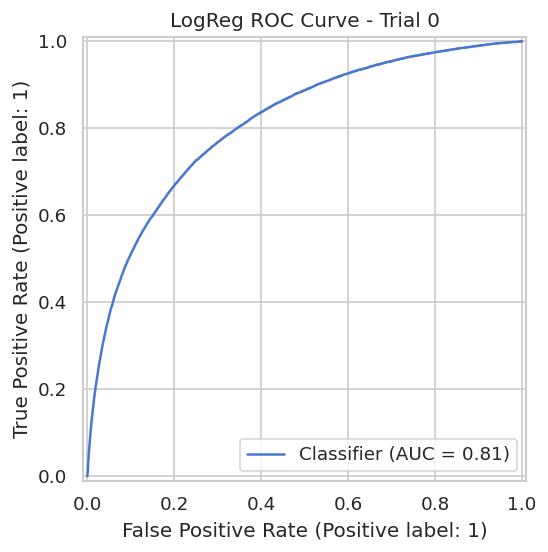


LogReg Trial 1
----------------------------------------------------------------------
Fold 1: Train AUC = 0.81072 | Val AUC = 0.81194
Fold 2: Train AUC = 0.81060 | Val AUC = 0.81366
Fold 3: Train AUC = 0.81170 | Val AUC = 0.80926
Fold 4: Train AUC = 0.81196 | Val AUC = 0.80728
Fold 5: Train AUC = 0.81151 | Val AUC = 0.80971

----------------------------------------------------------------------
Avg Train AUC : 0.81130
Avg Val   AUC : 0.81037
Overfit Gap   : 0.00093



<Figure size 768x576 with 0 Axes>

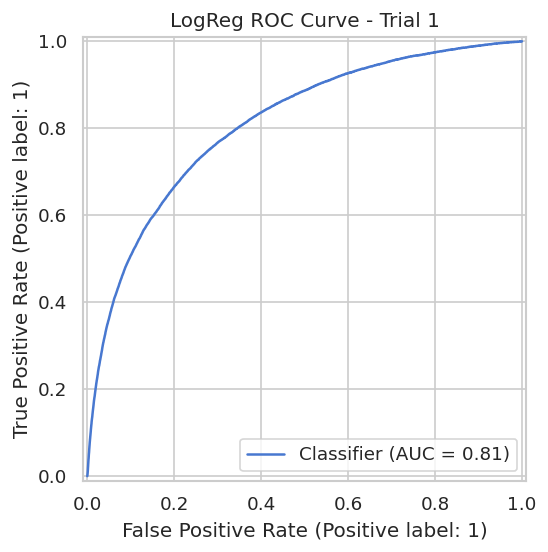


LogReg Trial 2
----------------------------------------------------------------------
Fold 1: Train AUC = 0.81408 | Val AUC = 0.81505
Fold 2: Train AUC = 0.81372 | Val AUC = 0.81729
Fold 3: Train AUC = 0.81499 | Val AUC = 0.81164
Fold 4: Train AUC = 0.81511 | Val AUC = 0.81086
Fold 5: Train AUC = 0.81482 | Val AUC = 0.81235

----------------------------------------------------------------------
Avg Train AUC : 0.81454
Avg Val   AUC : 0.81344
Overfit Gap   : 0.00111



<Figure size 768x576 with 0 Axes>

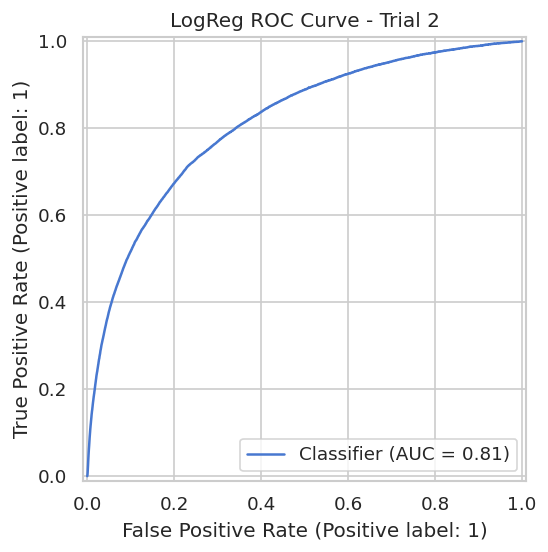


LogReg Trial 3
----------------------------------------------------------------------
Fold 1: Train AUC = 0.81410 | Val AUC = 0.81508
Fold 2: Train AUC = 0.81371 | Val AUC = 0.81729
Fold 3: Train AUC = 0.81500 | Val AUC = 0.81165
Fold 4: Train AUC = 0.81513 | Val AUC = 0.81088
Fold 5: Train AUC = 0.81484 | Val AUC = 0.81236

----------------------------------------------------------------------
Avg Train AUC : 0.81455
Avg Val   AUC : 0.81345
Overfit Gap   : 0.00110



<Figure size 768x576 with 0 Axes>

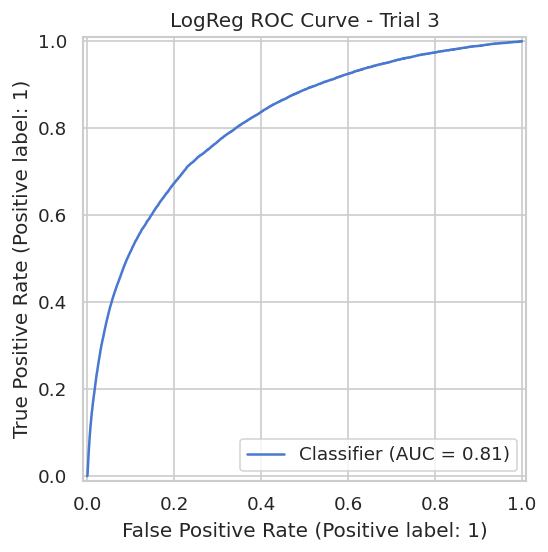


LogReg Trial 4
----------------------------------------------------------------------
Fold 1: Train AUC = 0.81090 | Val AUC = 0.81210
Fold 2: Train AUC = 0.81078 | Val AUC = 0.81385
Fold 3: Train AUC = 0.81186 | Val AUC = 0.80940
Fold 4: Train AUC = 0.81214 | Val AUC = 0.80748
Fold 5: Train AUC = 0.81168 | Val AUC = 0.80985

----------------------------------------------------------------------
Avg Train AUC : 0.81147
Avg Val   AUC : 0.81054
Overfit Gap   : 0.00094



<Figure size 768x576 with 0 Axes>

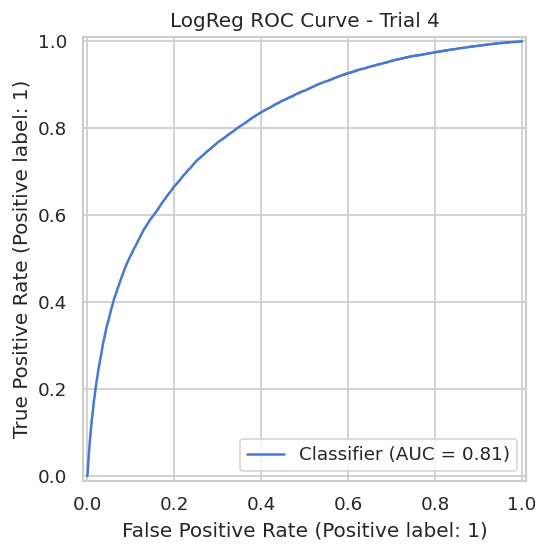


Best AUC: 0.8134505958907756
Best Params: {'C': 0.008435881228908617}


In [63]:
mlflow.set_experiment("logRegression")

study_lr = optuna.create_study(
    direction='maximize',
    study_name="LogReg_Fraud"
)

study_lr.optimize(objective_lr, n_trials=5)

print("\nBest AUC:", study_lr.best_value)
print("Best Params:", study_lr.best_params)

In [64]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SEED = 42

X = X_train_proc
y = y_train

import mlflow
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, RocCurveDisplay


def objective_adaboost(trial):

    mlflow.set_experiment("AdaBoost_Fraud")

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True),

        'estimator': DecisionTreeClassifier(
            max_depth=2,
            random_state=SEED
        ),

        'random_state': SEED
    }

    print("\n" + "="*60)
    print(f"AdaBoost Trial {trial.number}")
    print("="*60)

    val_scores, train_scores = [], []
    oof_preds = np.zeros(len(y))

    with mlflow.start_run(run_name=f"adaboost_trial_{trial.number}"):

        mlflow.log_params({
            k: v for k, v in params.items() if k != "estimator"
        })

        for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):

            X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
            X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

            model = AdaBoostClassifier(**params)

            model.fit(X_tr, y_tr)

            tr_pred = model.predict_proba(X_tr)[:, 1]
            val_pred = model.predict_proba(X_val)[:, 1]

            oof_preds[val_idx] = val_pred

            tr_auc = roc_auc_score(y_tr, tr_pred)
            val_auc = roc_auc_score(y_val, val_pred)

            train_scores.append(tr_auc)
            val_scores.append(val_auc)

            print(f"Fold {fold+1} | Train AUC: {tr_auc:.5f} | Val AUC: {val_auc:.5f}")

            mlflow.log_metric("train_auc", tr_auc, step=fold)
            mlflow.log_metric("val_auc", val_auc, step=fold)

        avg_train = np.mean(train_scores)
        avg_val = np.mean(val_scores)
        gap = avg_train - avg_val

        print("\n" + "-"*60)
        print(f"AVG Train AUC: {avg_train:.5f}")
        print(f"AVG Val   AUC: {avg_val:.5f}")
        print(f"Overfit Gap : {gap:.5f}")
        print("-"*60)

        mlflow.log_metric("avg_train_auc", avg_train)
        mlflow.log_metric("avg_val_auc", avg_val)
        mlflow.log_metric("overfit_gap", gap)

        RocCurveDisplay.from_predictions(y, oof_preds)
        plt.title(f"AdaBoost OOF ROC - Trial {trial.number}")
        plt.show()

        importance = model.feature_importances_
        indices = np.argsort(importance)[-20:]

        plt.figure(figsize=(10, 6))
        plt.barh(range(len(indices)), importance[indices])
        plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
        plt.title(f"AdaBoost Feature Importance - Trial {trial.number}")
        plt.tight_layout()

        plot_path = f"adaboost_fi_trial_{trial.number}.png"
        plt.savefig(plot_path)
        mlflow.log_artifact(plot_path)
        plt.close()

        return avg_val

In [ ]:
mlflow.set_experiment("AdaBoost")

study_ada = optuna.create_study(direction="maximize", study_name="AdaBoost_Fraud")
study_ada.optimize(objective_adaboost, n_trials=3)


AdaBoost Trial 0
Fold 1 | Train AUC: 0.85858 | Val AUC: 0.85868
Fold 2 | Train AUC: 0.85767 | Val AUC: 0.86054
Fold 3 | Train AUC: 0.85885 | Val AUC: 0.85577
